In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kaziakaid/dataset-updadet/updated_thesis_dataset_v3.csv


In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.inspection import PartialDependenceDisplay



In [4]:
# ============================================================
# 1. LOAD DATA
# ============================================================

csv_path = "/kaggle/input/datasets/kaziakaid/dataset-updadet/updated_thesis_dataset_v3.csv"
df = pd.read_csv(csv_path, encoding="unicode_escape")

print("=" * 70)
print("DATA LOADED")
print("=" * 70)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))


DATA LOADED
Shape: (341, 10)
Columns: ['Paper_ID', 'Title', 'Cellulose_Source', 'Acid_Type', 'Acid_conc_wt_percent', 'Temp_C', 'Time_min', 'Crystallinity_percent', 'CNC_Length_nm', 'Cellulose_Group']
  Paper_ID                                              Title  \
0     P001  Influence of mechanical pretreatment to isolat...   
1     P002  Preparation and Characterization of Cellulose ...   
2     P002  Preparation and Characterization of Cellulose ...   

           Cellulose_Source Acid_Type  Acid_conc_wt_percent  Temp_C  Time_min  \
0  Bleached eucalyptus pulp     H2SO4                  55.0    65.0     150.0   
1               Ramie fiber     H2SO4                  58.0    45.0      30.0   
2               Ramie fiber     H2SO4                  58.0    65.0      30.0   

   Crystallinity_percent CNC_Length_nm      Cellulose_Group  
0                  70.00           250    Wood / Pulp-based  
1                  90.77        145.61  Natural Plant Fiber  
2                  80.32    

In [5]:
# ============================================================
# DATASET ANALYSIS / EDA PLOTS
# ============================================================

import seaborn as sns

eda_df = df.copy()

# Convert numeric columns
numeric_cols = ["Acid_conc_wt_percent", "Temp_C", "Time_min",
                "Crystallinity_percent", "CNC_Length_nm"]

for col in numeric_cols:
    eda_df[col] = pd.to_numeric(eda_df[col], errors="coerce")

In [6]:
# ============================================================
# 2. SETTINGS
# ============================================================

FEATURES = ["Cellulose_Group", "Acid_conc_wt_percent", "Temp_C", "Time_min"]

TARGETS = {
    "Crystallinity_percent": "Crystallinity (%)",
    "CNC_Length_nm": "CNC Length (nm)"
}

MODELS = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=8, random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200, max_depth=8, random_state=42
    ),
    "SVR": SVR(kernel="rbf", C=10, epsilon=0.1)
}

PLOT_MODELS = [
    "Linear Regression",
    "Random Forest",
    "Gradient Boosting",
    "Extra Trees"
]

COLORS = {
    "Linear Regression": "#4e79a7",
    "Ridge": "#9c755f",
    "Lasso": "#bab0ab",
    "Random Forest": "#f28e2b",
    "Gradient Boosting": "#e15759",
    "Extra Trees": "#76b7b2",
    "SVR": "#59a14f",
    "RF Tuned": "#edc948"
}

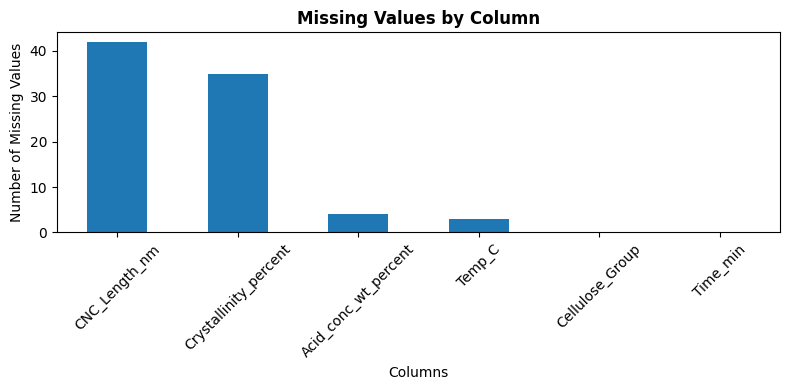

Saved -> fig_dataset_missing_values.png


In [7]:
# 1. Missing values count
missing_counts = eda_df[FEATURES + list(TARGETS.keys())].isna().sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
missing_counts.plot(kind="bar")
plt.title("Missing Values by Column", fontweight="bold")
plt.ylabel("Number of Missing Values")
plt.xlabel("Columns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig_dataset_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> fig_dataset_missing_values.png")

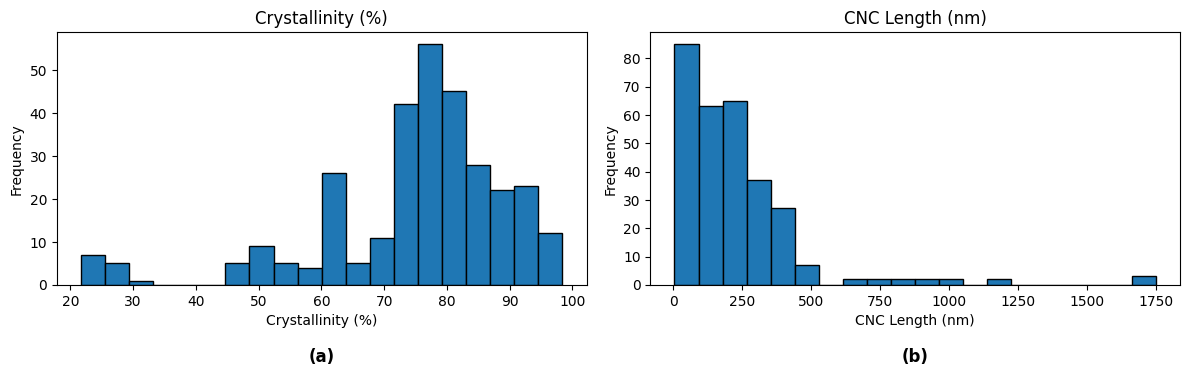

In [8]:
# 2. Target distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


targets = ["Crystallinity_percent", "CNC_Length_nm"]
titles = ["Crystallinity (%)", "CNC Length (nm)"]
labels = ['(a)', '(b)']

for i, ax in enumerate(axes):
    ax.hist(eda_df[targets[i]].dropna(), bins=20, edgecolor="black")
    ax.set_title(titles[i])
    ax.set_xlabel(titles[i])
    ax.set_ylabel("Frequency")
    
    # 👇 label BELOW subplot
    ax.text(0.5, -0.25, labels[i], transform=ax.transAxes,
            fontsize=12, fontweight='bold', ha='center', va='top')

plt.tight_layout()
plt.savefig("fig_dataset_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

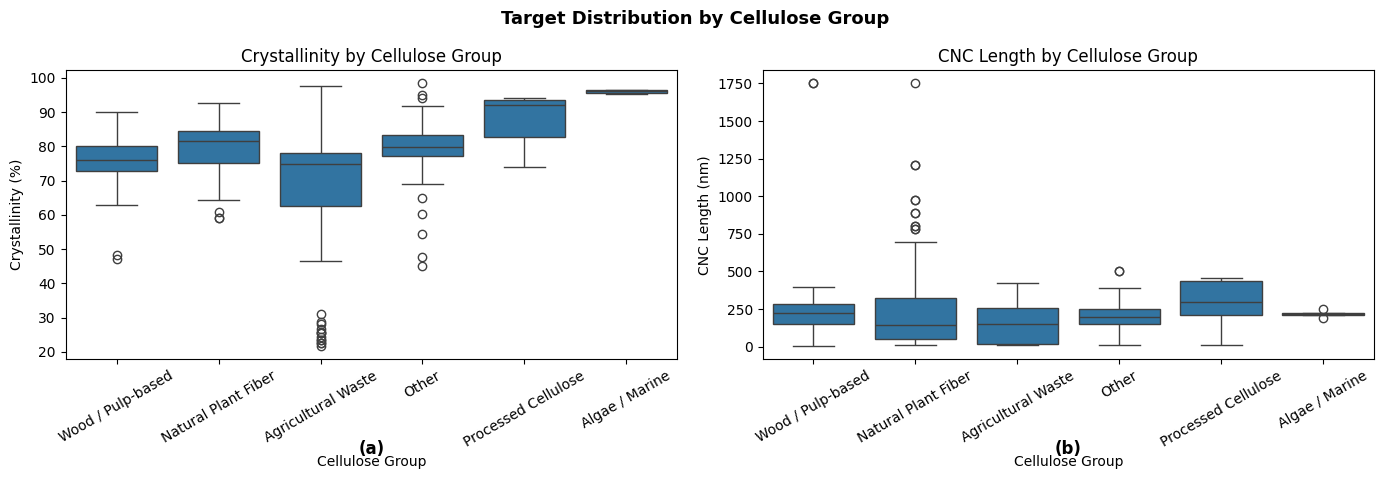

Saved -> fig_dataset_group_boxplot.png


In [9]:
# 3. Boxplots by cellulose group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Target Distribution by Cellulose Group", fontsize=13, fontweight="bold")

sns.boxplot(data=eda_df, x="Cellulose_Group", y="Crystallinity_percent", ax=axes[0])
axes[0].set_title("Crystallinity by Cellulose Group")
axes[0].set_xlabel("Cellulose Group")
axes[0].set_ylabel("Crystallinity (%)")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=eda_df, x="Cellulose_Group", y="CNC_Length_nm", ax=axes[1])
axes[1].set_title("CNC Length by Cellulose Group")
axes[1].set_xlabel("Cellulose Group")
axes[1].set_ylabel("CNC Length (nm)")
axes[1].tick_params(axis="x", rotation=30)

# 👇 subplot labels BELOW each plot
labels = ['(a)', '(b)']

axes[0].text(0.5, -0.28, labels[0], transform=axes[0].transAxes,
             fontsize=12, fontweight='bold', ha='center', va='top')

axes[1].text(0.5, -0.28, labels[1], transform=axes[1].transAxes,
             fontsize=12, fontweight='bold', ha='center', va='top')

plt.tight_layout()
plt.savefig("fig_dataset_group_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> fig_dataset_group_boxplot.png")

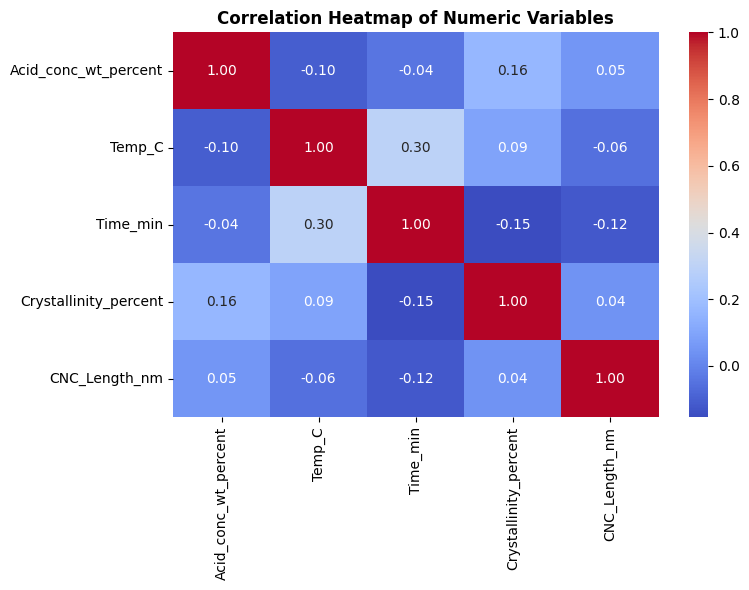

Saved -> fig_dataset_correlation_heatmap.png


In [10]:
# 4. Correlation heatmap
corr_cols = ["Acid_conc_wt_percent", "Temp_C", "Time_min",
             "Crystallinity_percent", "CNC_Length_nm"]

corr_df = eda_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_dataset_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> fig_dataset_correlation_heatmap.png")

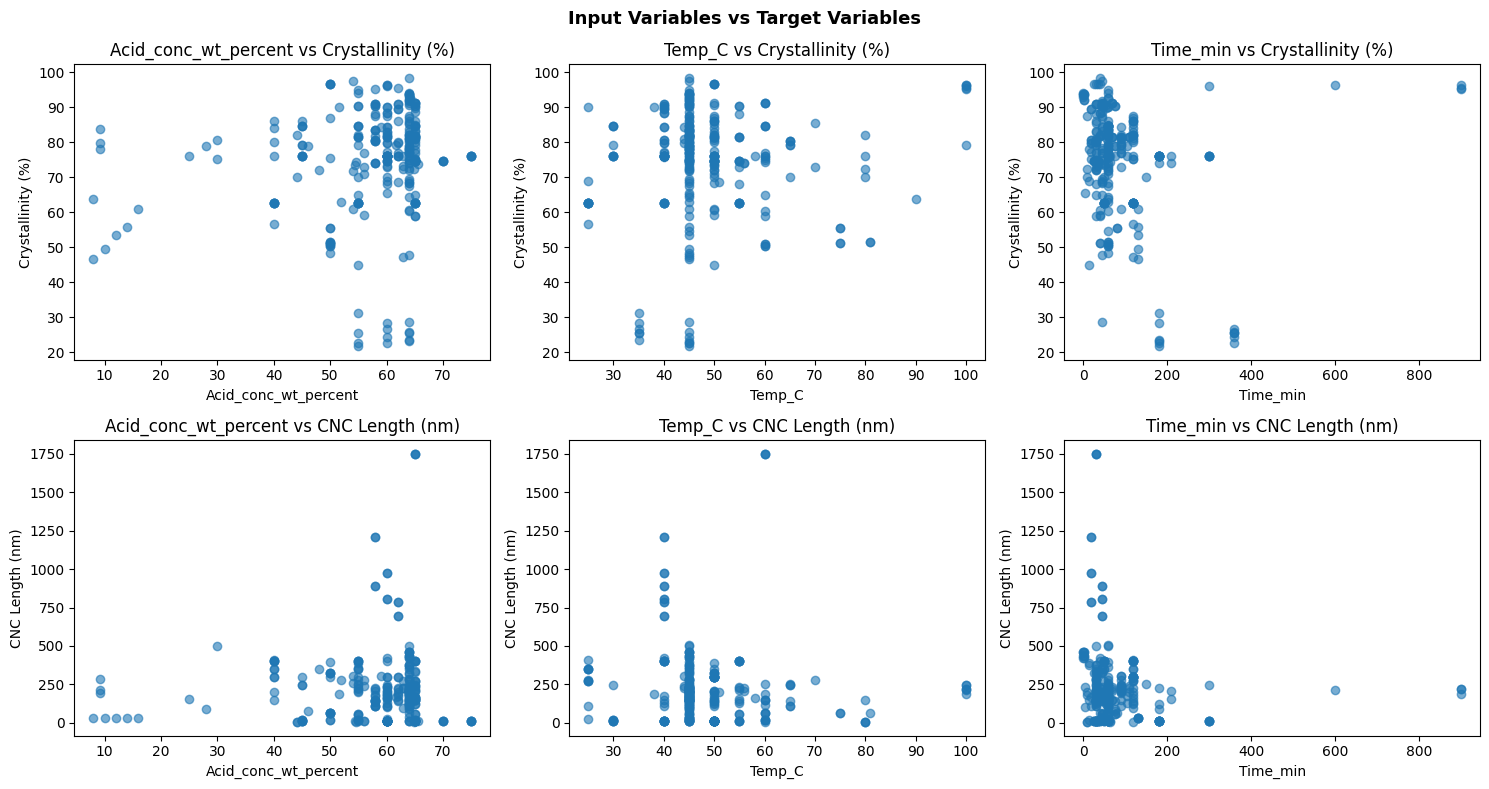

Saved -> fig_dataset_scatter_inputs_targets.png


In [11]:
# 5. Scatter plots: inputs vs targets
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Input Variables vs Target Variables", fontsize=13, fontweight="bold")

input_vars = ["Acid_conc_wt_percent", "Temp_C", "Time_min"]
target_vars = ["Crystallinity_percent", "CNC_Length_nm"]
target_labels = ["Crystallinity (%)", "CNC Length (nm)"]


for row, (target, target_label) in enumerate(zip(target_vars, target_labels)):
    for col, feature in enumerate(input_vars):
        ax = axes[row, col]
        ax.scatter(eda_df[feature], eda_df[target], alpha=0.6)
        ax.set_xlabel(feature)
        ax.set_ylabel(target_label)
        ax.set_title(f"{feature} vs {target_label}")

plt.tight_layout()
plt.savefig("fig_dataset_scatter_inputs_targets.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> fig_dataset_scatter_inputs_targets.png")

In [12]:
# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def prepare_data(df, features, targets):
    cols = features + list(targets.keys())
    data = df[cols].copy()

    numeric_cols = ["Acid_conc_wt_percent", "Temp_C", "Time_min"] + list(targets.keys())
    for col in numeric_cols:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    data = pd.get_dummies(data, columns=["Cellulose_Group"], drop_first=False)
    feature_cols = [c for c in data.columns if c not in targets]

    return data, feature_cols


def build_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])


def split_for_target(data, feature_cols, target, test_size=0.25, random_state=42):
    subset = data[feature_cols + [target]].dropna(subset=[target])
    X = subset[feature_cols]
    y = subset[target]
    return train_test_split(X, y, test_size=test_size, random_state=random_state)


def evaluate_model(pipe, X_train, X_test, y_train, y_test):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    return {
        "pipe": pipe,
        "y_pred": y_pred,
        "R2": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred)
    }


def print_metric_table(results, target, label, model_names):
    print(f"\n--- {label} ---")
    print(f"{'Model':<22} {'R²':>8} {'RMSE':>10} {'MAE':>10}")
    print("-" * 56)
    for name in model_names:
        r = results[target][name]
        print(f"{name:<22} {r['R2']:>8.3f} {r['RMSE']:>10.2f} {r['MAE']:>10.2f}")


def get_feature_importance(pipe, feature_names):
    model = pipe.named_steps["model"]
    if hasattr(model, "feature_importances_"):
        vals = model.feature_importances_
        return pd.DataFrame({
            "Feature": feature_names,
            "Importance": vals
        }).sort_values("Importance", ascending=False).reset_index(drop=True)
    return None


def choose_best_model(results, target):
    ranking = []
    for model_name, r in results[target].items():
        ranking.append((model_name, r["R2"], r["RMSE"]))
    ranking = sorted(ranking, key=lambda x: (-x[1], x[2]))
    return ranking[0][0]


In [13]:
# ============================================================
# 4. DATA PREPARATION
# ============================================================

data, feature_cols = prepare_data(df, FEATURES, TARGETS)

readable_names = [
    c.replace("Cellulose_Group_", "") if c.startswith("Cellulose_Group_") else c
    for c in feature_cols
]

print("\n" + "=" * 70)
print("DATA PREPARED")
print("=" * 70)
print("Feature columns:", feature_cols)

for target in TARGETS:
    print(f"{target} available rows: {data[target].notna().sum()}")


# ============================================================
# 5. TRAIN / TEST SPLITS
# ============================================================

splits = {}

for target in TARGETS:
    X_train, X_test, y_train, y_test = split_for_target(data, feature_cols, target)
    splits[target] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

print("\n" + "=" * 70)
print("TRAIN / TEST SPLITS")
print("=" * 70)
for target, label in TARGETS.items():
    print(f"{label:<20} Train: {len(splits[target]['X_train'])} | Test: {len(splits[target]['X_test'])}")




DATA PREPARED
Feature columns: ['Acid_conc_wt_percent', 'Temp_C', 'Time_min', 'Cellulose_Group_Agricultural Waste', 'Cellulose_Group_Algae / Marine', 'Cellulose_Group_Natural Plant Fiber', 'Cellulose_Group_Other', 'Cellulose_Group_Processed Cellulose', 'Cellulose_Group_Wood / Pulp-based']
Crystallinity_percent available rows: 306
CNC_Length_nm available rows: 299

TRAIN / TEST SPLITS
Crystallinity (%)    Train: 229 | Test: 77
CNC Length (nm)      Train: 224 | Test: 75


In [14]:
# ============================================================
# 6. MODEL TRAINING & EVALUATION
# ============================================================

results = {target: {} for target in TARGETS}

print("\n" + "=" * 70)
print("MODEL TRAINING & EVALUATION")
print("=" * 70)

for target, label in TARGETS.items():
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    for model_name, model in MODELS.items():
        pipe = build_pipeline(model)
        results[target][model_name] = evaluate_model(pipe, X_train, X_test, y_train, y_test)

    print_metric_table(results, target, label, list(MODELS.keys()))


MODEL TRAINING & EVALUATION

--- Crystallinity (%) ---
Model                        R²       RMSE        MAE
--------------------------------------------------------
Linear Regression         0.284      11.90       8.88
Ridge                     0.294      11.82       8.85
Lasso                     0.285      11.89       8.87
Random Forest             0.643       8.40       5.64
Gradient Boosting         0.618       8.68       5.56
Extra Trees               0.707       7.61       5.07
SVR                       0.374      11.12       7.37

--- CNC Length (nm) ---
Model                        R²       RMSE        MAE
--------------------------------------------------------
Linear Regression         0.072     234.55     147.31
Ridge                     0.071     234.63     147.42
Lasso                     0.072     234.55     147.31
Random Forest             0.794     110.60      81.81
Gradient Boosting         0.861      90.71      67.07
Extra Trees               0.778     114.61      8

In [15]:
# ============================================================
# 7. CROSS-VALIDATION
# ============================================================

cv_models = ["Random Forest", "Gradient Boosting", "Extra Trees", "SVR"]

print("\n" + "=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("=" * 70)

for target, label in TARGETS.items():
    X_train = splits[target]["X_train"]
    y_train = splits[target]["y_train"]

    print(f"\n--- {label} ---")
    for model_name in cv_models:
        pipe = build_pipeline(MODELS[model_name])
        scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2")
        print(f"{model_name:<20} CV R² = {scores.mean():.3f} ± {scores.std():.3f}")




5-FOLD CROSS-VALIDATION

--- Crystallinity (%) ---
Random Forest        CV R² = 0.433 ± 0.216
Gradient Boosting    CV R² = 0.436 ± 0.195
Extra Trees          CV R² = 0.532 ± 0.156
SVR                  CV R² = 0.110 ± 0.102

--- CNC Length (nm) ---
Random Forest        CV R² = 0.519 ± 0.257
Gradient Boosting    CV R² = 0.456 ± 0.298
Extra Trees          CV R² = 0.405 ± 0.353
SVR                  CV R² = -0.039 ± 0.023


In [16]:
# ============================================================
# 8. HYPERPARAMETER TUNING — RANDOM FOREST
# ============================================================

print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING — RANDOM FOREST")
print("=" * 70)

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 8, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

for target, label in TARGETS.items():
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    pipe = build_pipeline(RandomForestRegressor(random_state=42))
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring="r2", n_jobs=-1)
    grid.fit(X_train, y_train)

    y_pred = grid.best_estimator_.predict(X_test)

    results[target]["RF Tuned"] = {
        "pipe": grid.best_estimator_,
        "y_pred": y_pred,
        "R2": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred)
    }

    print(f"\n--- {label} ---")
    print("Best params:", grid.best_params_)
    print(f"Test R²   : {results[target]['RF Tuned']['R2']:.3f}")
    print(f"Test RMSE : {results[target]['RF Tuned']['RMSE']:.2f}")
    print(f"Test MAE  : {results[target]['RF Tuned']['MAE']:.2f}")




HYPERPARAMETER TUNING — RANDOM FOREST

--- Crystallinity (%) ---
Best params: {'model__max_depth': 8, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Test R²   : 0.643
Test RMSE : 8.40
Test MAE  : 5.64

--- CNC Length (nm) ---
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Test R²   : 0.784
Test RMSE : 113.11
Test MAE  : 81.21


In [17]:
# ============================================================
# 9. FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE — TREE MODELS")
print("=" * 70)

for target, label in TARGETS.items():
    print(f"\n--- {label} ---")
    for model_name in ["Random Forest", "Gradient Boosting", "Extra Trees"]:
        imp_df = get_feature_importance(results[target][model_name]["pipe"], readable_names)
        if imp_df is not None:
            print(f"\n{model_name}")
            print(imp_df.to_string(index=False))




FEATURE IMPORTANCE — TREE MODELS

--- Crystallinity (%) ---

Random Forest
             Feature  Importance
              Temp_C    0.320056
            Time_min    0.264347
Acid_conc_wt_percent    0.228990
 Natural Plant Fiber    0.122612
  Agricultural Waste    0.028144
   Wood / Pulp-based    0.022640
 Processed Cellulose    0.007304
               Other    0.005653
      Algae / Marine    0.000252

Gradient Boosting
             Feature  Importance
              Temp_C    0.501167
            Time_min    0.207833
Acid_conc_wt_percent    0.161845
 Natural Plant Fiber    0.086958
  Agricultural Waste    0.017825
   Wood / Pulp-based    0.010515
 Processed Cellulose    0.009746
               Other    0.004104
      Algae / Marine    0.000007

Extra Trees
             Feature  Importance
              Temp_C    0.436645
Acid_conc_wt_percent    0.220247
            Time_min    0.214624
  Agricultural Waste    0.053721
 Natural Plant Fiber    0.038998
               Other    0.018884
 

In [18]:
# ============================================================
# 10. SUMMARY TABLE
# ============================================================

summary_rows = []

for target, label in TARGETS.items():
    for model_name, r in results[target].items():
        summary_rows.append({
            "Target": label,
            "Model": model_name,
            "R²": round(r["R2"], 3),
            "RMSE": round(r["RMSE"], 2),
            "MAE": round(r["MAE"], 2)
        })

summary_df = pd.DataFrame(summary_rows)

print("\n" + "=" * 70)
print("FINAL SUMMARY TABLE")
print("=" * 70)
print(summary_df.sort_values(["Target", "R²"], ascending=[True, False]).to_string(index=False))



FINAL SUMMARY TABLE
           Target             Model    R²   RMSE    MAE
  CNC Length (nm) Gradient Boosting 0.861  90.71  67.07
  CNC Length (nm)     Random Forest 0.794 110.60  81.81
  CNC Length (nm)          RF Tuned 0.784 113.11  81.21
  CNC Length (nm)       Extra Trees 0.778 114.61  85.82
  CNC Length (nm) Linear Regression 0.072 234.55 147.31
  CNC Length (nm)             Lasso 0.072 234.55 147.31
  CNC Length (nm)             Ridge 0.071 234.63 147.42
  CNC Length (nm)               SVR 0.037 238.94 140.48
Crystallinity (%)       Extra Trees 0.707   7.61   5.07
Crystallinity (%)     Random Forest 0.643   8.40   5.64
Crystallinity (%)          RF Tuned 0.643   8.40   5.64
Crystallinity (%) Gradient Boosting 0.618   8.68   5.56
Crystallinity (%)               SVR 0.374  11.12   7.37
Crystallinity (%)             Ridge 0.294  11.82   8.85
Crystallinity (%)             Lasso 0.285  11.89   8.87
Crystallinity (%) Linear Regression 0.284  11.90   8.88


In [19]:
# ============================================================
# 11. CHOOSE BEST MODEL AUTOMATICALLY
# ============================================================

best_model = {
    target: choose_best_model(results, target)
    for target in TARGETS
}

print("\n" + "=" * 70)
print("BEST MODEL PER TARGET")
print("=" * 70)
for target, label in TARGETS.items():
    print(f"{label}: {best_model[target]}")




BEST MODEL PER TARGET
Crystallinity (%): Extra Trees
CNC Length (nm): Gradient Boosting


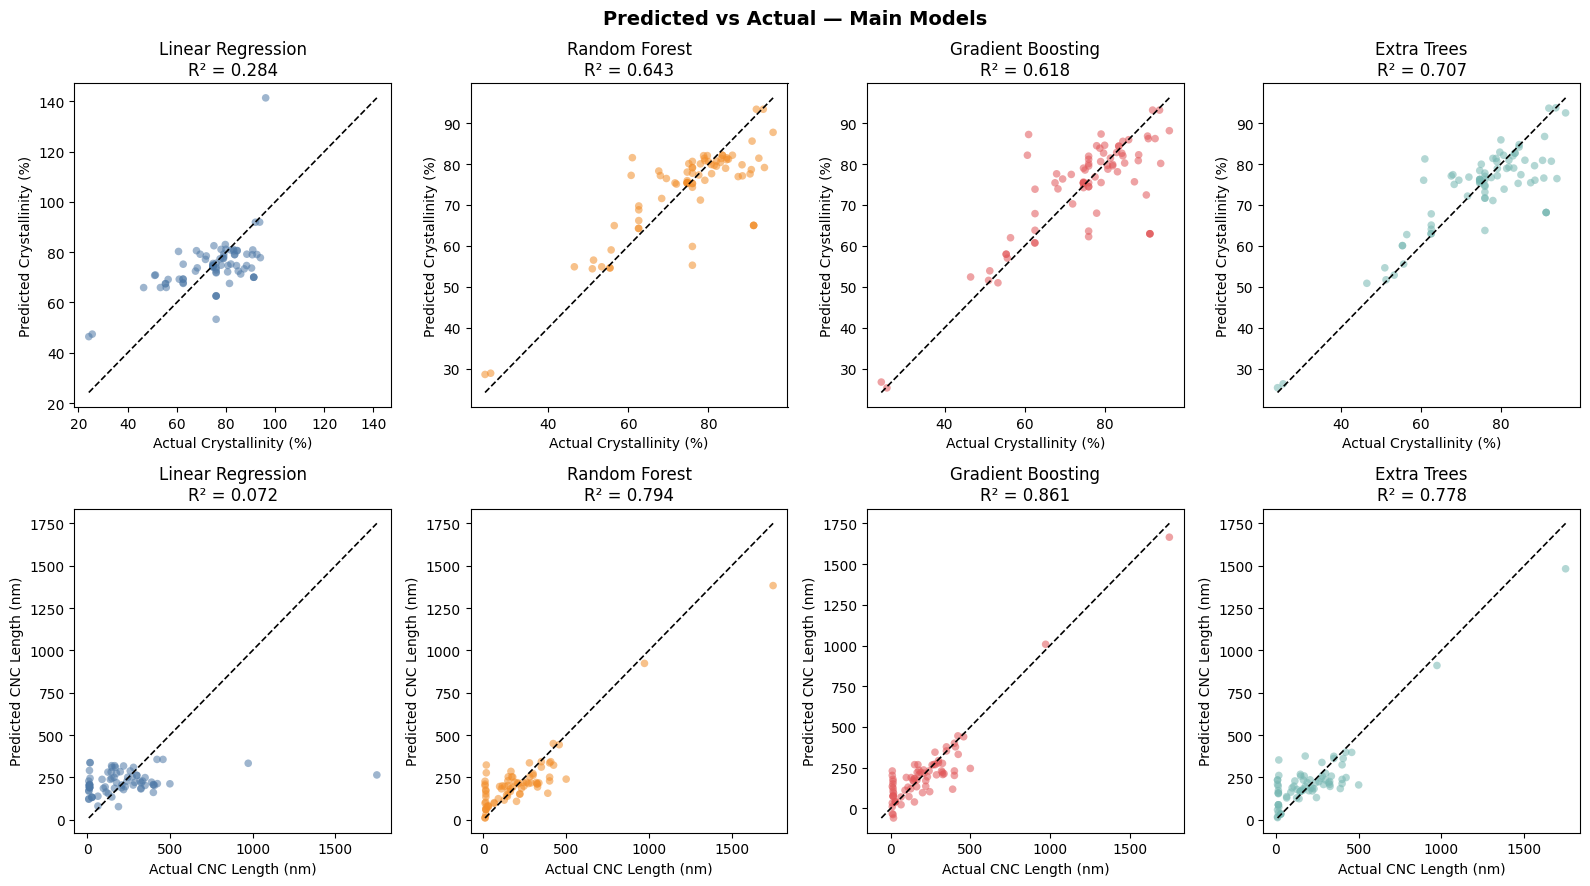

Saved -> fig1_predicted_vs_actual.png


In [20]:
# ============================================================
# 12A. PREDICTED VS ACTUAL — MAIN MODELS
# ============================================================

fig, axes = plt.subplots(2, len(PLOT_MODELS), figsize=(4*len(PLOT_MODELS), 9))
fig.suptitle("Predicted vs Actual — Main Models", fontsize=14, fontweight="bold")

for row, (target, label) in enumerate(TARGETS.items()):
    y_test = splits[target]["y_test"]

    for col, model_name in enumerate(PLOT_MODELS):
        ax = axes[row, col]
        y_pred = results[target][model_name]["y_pred"]
        r2 = results[target][model_name]["R2"]

        ax.scatter(y_test, y_pred, alpha=0.55, s=30, color=COLORS[model_name], edgecolors="none")
        mn = min(y_test.min(), y_pred.min())
        mx = max(y_test.max(), y_pred.max())
        ax.plot([mn, mx], [mn, mx], "k--", lw=1.2)

        ax.set_xlabel(f"Actual {label}")
        ax.set_ylabel(f"Predicted {label}")
        ax.set_title(f"{model_name}\nR² = {r2:.3f}")

plt.tight_layout()
plt.savefig("fig1_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> fig1_predicted_vs_actual.png")



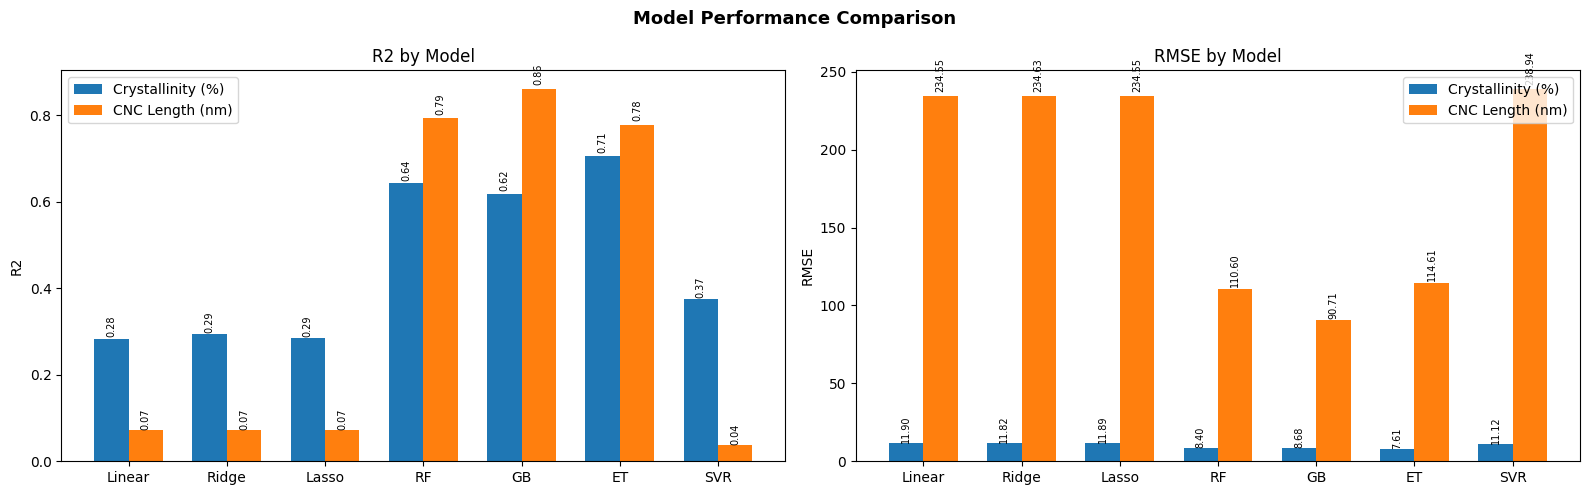

Saved -> fig2_model_comparison.png


In [21]:

# ============================================================
# 12B. MODEL COMPARISON BAR CHART
# ============================================================

compare_models = ["Linear Regression", "Ridge", "Lasso", "Random Forest", "Gradient Boosting", "Extra Trees", "SVR"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Model Performance Comparison", fontsize=13, fontweight="bold")

for ax, metric in zip(axes, ["R2", "RMSE"]):
    x = np.arange(len(compare_models))
    width = 0.35

    cry_vals = [results["Crystallinity_percent"][m][metric] for m in compare_models]
    len_vals = [results["CNC_Length_nm"][m][metric] for m in compare_models]

    bars1 = ax.bar(x - width/2, cry_vals, width, label="Crystallinity (%)")
    bars2 = ax.bar(x + width/2, len_vals, width, label="CNC Length (nm)")

    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f"{bar.get_height():.2f}",
                ha="center", va="bottom", fontsize=7, rotation=90
            )

    ax.set_xticks(x)
    ax.set_xticklabels(
        ["Linear", "Ridge", "Lasso", "RF", "GB", "ET", "SVR"],
        rotation=0
    )
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} by Model")
    ax.legend()

plt.tight_layout()
plt.savefig("fig2_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> fig2_model_comparison.png")


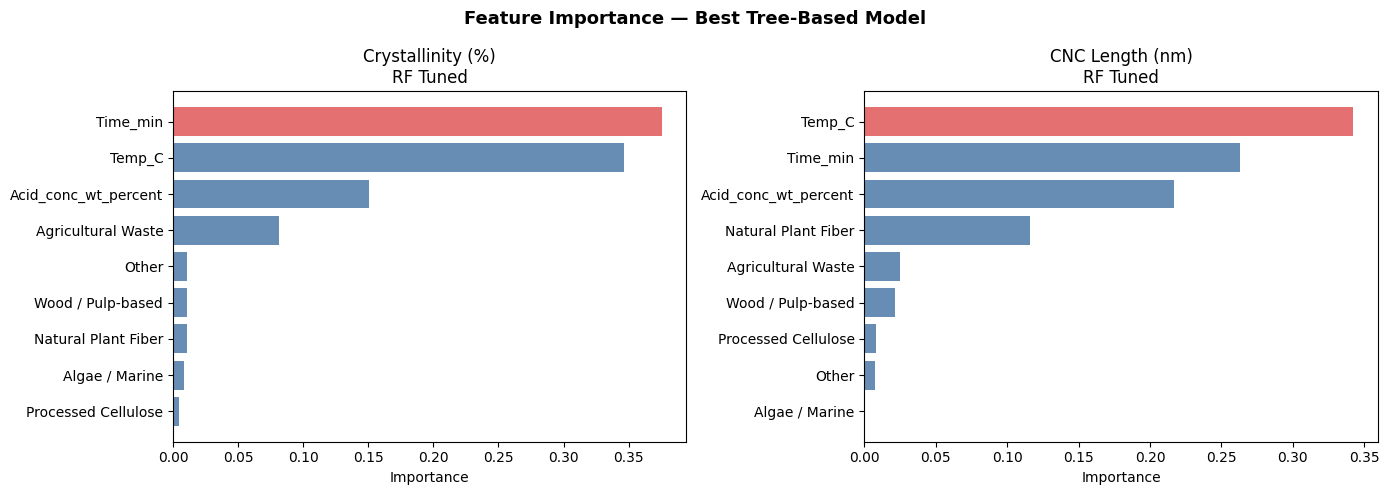

Saved -> fig3_feature_importance.png


In [22]:
# ============================================================
# 12C. FEATURE IMPORTANCE PLOTS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Feature Importance — Best Tree-Based Model", fontsize=13, fontweight="bold")

for ax, (target, label) in zip(axes, TARGETS.items()):
    candidate_models = ["RF Tuned", "Random Forest", "Gradient Boosting", "Extra Trees"]
    chosen = None
    for m in candidate_models:
        if m in results[target] and hasattr(results[target][m]["pipe"].named_steps["model"], "feature_importances_"):
            chosen = m
            break

    pipe = results[target][chosen]["pipe"]
    imp_df = get_feature_importance(pipe, readable_names)

    colors = ["#e15759" if v == imp_df["Importance"].max() else "#4e79a7"
              for v in imp_df["Importance"]]

    ax.barh(imp_df["Feature"], imp_df["Importance"], color=colors, alpha=0.85)
    ax.set_xlabel("Importance")
    ax.set_title(f"{label}\n{chosen}")
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig("fig3_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> fig3_feature_importance.png")


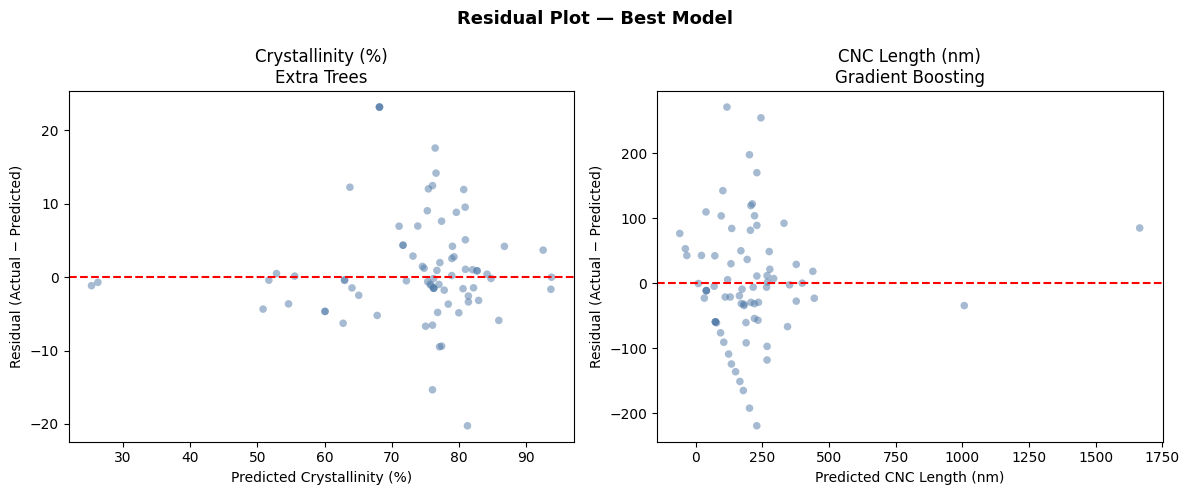

Saved -> fig4_residuals.png


In [23]:
# ============================================================
# 12D. RESIDUAL PLOTS — BEST MODEL
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Residual Plot — Best Model", fontsize=13, fontweight="bold")

for ax, (target, label) in zip(axes, TARGETS.items()):
    model_name = best_model[target]
    y_test = splits[target]["y_test"]
    y_pred = results[target][model_name]["y_pred"]
    resid = y_test - y_pred

    ax.scatter(y_pred, resid, alpha=0.5, s=30, color="#4e79a7", edgecolors="none")
    ax.axhline(0, color="red", linestyle="--", lw=1.5)
    ax.set_xlabel(f"Predicted {label}")
    ax.set_ylabel("Residual (Actual − Predicted)")
    ax.set_title(f"{label}\n{model_name}")

plt.tight_layout()
plt.savefig("fig4_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> fig4_residuals.png")


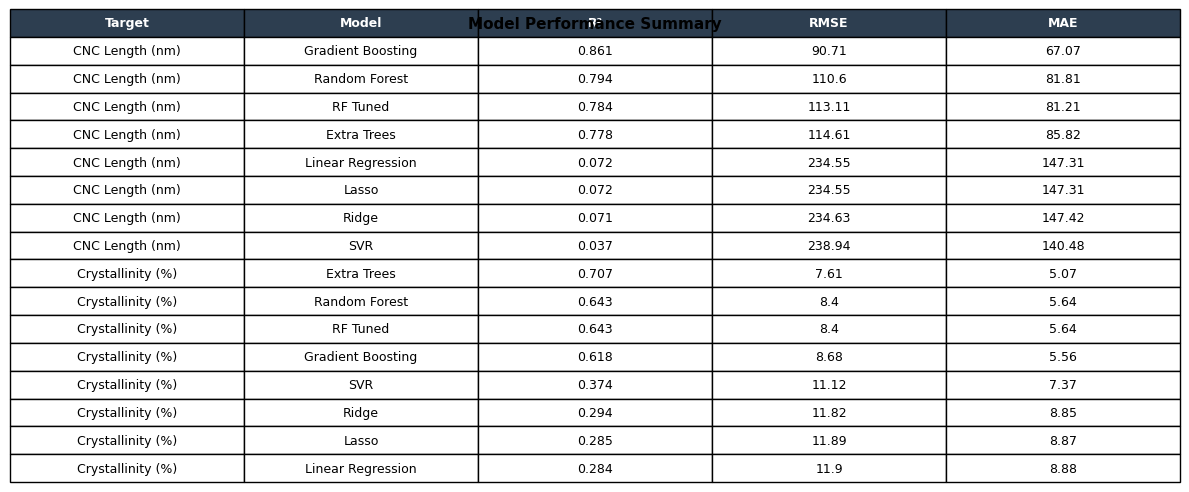

Saved -> fig5_summary_table.png


In [24]:
# ============================================================
# 12E. SUMMARY TABLE FIGURE
# ============================================================

summary_plot_df = summary_df.copy()
summary_plot_df = summary_plot_df.sort_values(["Target", "R²"], ascending=[True, False]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")

table = ax.table(
    cellText=summary_plot_df.values,
    colLabels=summary_plot_df.columns,
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

for j in range(len(summary_plot_df.columns)):
    table[(0, j)].set_facecolor("#2d3e50")
    table[(0, j)].set_text_props(color="white", fontweight="bold")

ax.set_title("Model Performance Summary", pad=12, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("fig5_summary_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> fig5_summary_table.png")


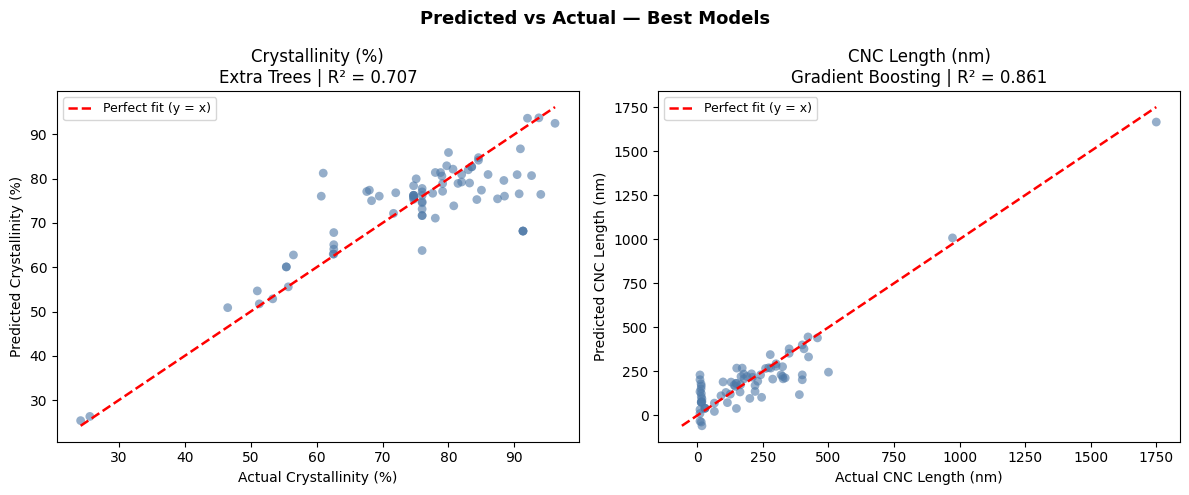

Saved -> fig_pred_vs_actual.png


In [25]:
# ============================================================
# 13. BEST MODEL PLOTS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Predicted vs Actual — Best Models", fontsize=13, fontweight="bold")

for ax, (target, label) in zip(axes, TARGETS.items()):
    y_test = splits[target]["y_test"]
    model_name = best_model[target]
    y_pred = results[target][model_name]["y_pred"]
    r2 = results[target][model_name]["R2"]

    ax.scatter(y_test, y_pred, alpha=0.6, s=40, color="#4e79a7", edgecolors="none")
    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], "r--", lw=1.8, label="Perfect fit (y = x)")

    ax.set_xlabel(f"Actual {label}")
    ax.set_ylabel(f"Predicted {label}")
    ax.set_title(f"{label}\n{model_name} | R² = {r2:.3f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> fig_pred_vs_actual.png")





In [26]:
# ============================================================
# 14. ADVANCED PLOT SETUP
# ============================================================

group_cols = [c for c in feature_cols if c.startswith("Cellulose_Group_")]

most_common_group = df["Cellulose_Group"].mode()[0]
most_common_group_col = f"Cellulose_Group_{most_common_group}"

print("=" * 70)
print("ADVANCED PLOT SETUP")
print("=" * 70)
print("Group columns:", group_cols)
print("Most common Cellulose_Group:", most_common_group)
print("Reference one-hot column:", most_common_group_col)

ADVANCED PLOT SETUP
Group columns: ['Cellulose_Group_Agricultural Waste', 'Cellulose_Group_Algae / Marine', 'Cellulose_Group_Natural Plant Fiber', 'Cellulose_Group_Other', 'Cellulose_Group_Processed Cellulose', 'Cellulose_Group_Wood / Pulp-based']
Most common Cellulose_Group: Agricultural Waste
Reference one-hot column: Cellulose_Group_Agricultural Waste


In [27]:
import joblib

model_bundle = {
    "length_model": results["CNC_Length_nm"]["RF Tuned"]["pipe"],
    "crystallinity_model": results["Crystallinity_percent"]["RF Tuned"]["pipe"],
    "feature_cols": feature_cols,
    "cellulose_groups": df["Cellulose_Group"].unique().tolist()
}
joblib.dump(model_bundle, "/kaggle/working/nanocnc_model_bundle.pkl")
print("Model saved!")


Model saved!


In [28]:
import sklearn, joblib
print("Kaggle sklearn version:", sklearn.__version__)

# Resave with current Kaggle sklearn
joblib.dump(model_bundle, "nanocnc_model_bundle.pkl")
print("Done! Download this file from Kaggle output.")

Kaggle sklearn version: 1.6.1
Done! Download this file from Kaggle output.
